# Aula 12: Atividade

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from graph_tool.all import *

In [2]:
sns.set()

In [3]:
g = load_graph('call4u.gt')

Text(0, 0.5, 'evasao')

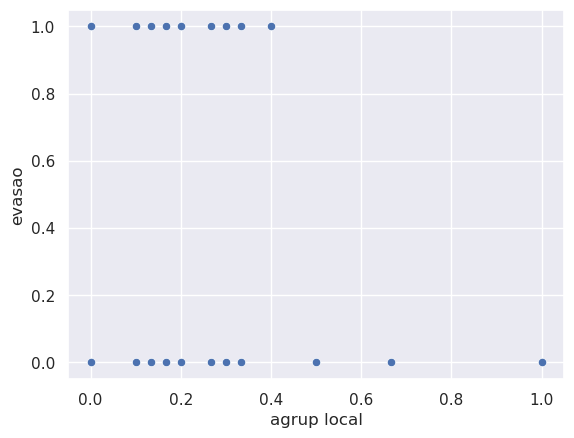

In [4]:
proximidade = local_clustering(g)
evasao = [g.vp['evasao'][v] for v in g.vertices()]
senioridade = [g.vp['senioridade'][v] for v in g.vertices()]

df = pd.DataFrame({
    'agrup local': proximidade,
    'evasao': evasao,
    'senioridade': senioridade,
})

p = sns.scatterplot(data=df, x='agrup local', y='evasao')
p.set_xlabel('agrup local')
p.set_ylabel('evasao')

Text(0, 0.5, 'evasao')

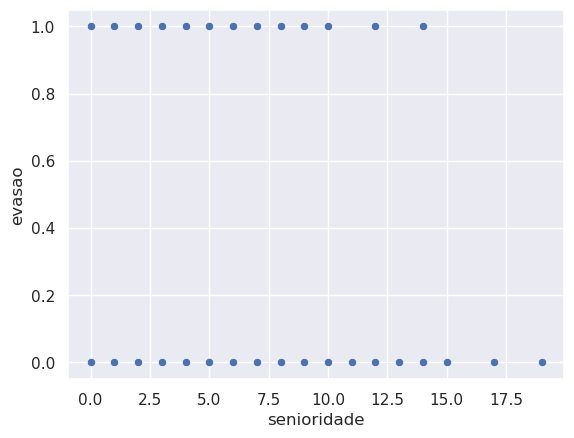

In [8]:
p = sns.scatterplot(data=df, x='senioridade', y='evasao')
p.set_xlabel('senioridade')
p.set_ylabel('evasao')

In [6]:
dep = df['evasao']
ind = ind = df[['agrup local', 'senioridade']]
ind = sm.add_constant(ind)
model = sm.OLS(dep, ind)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 evasao   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     12.28
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.42e-05
Time:                        14:14:33   Log-Likelihood:                -73.295
No. Observations:                 122   AIC:                             152.6
Df Residuals:                     119   BIC:                             161.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6767      0.079      8.535      0.000       0.520       0.834
agrup local    -0.5824      0.141     -4.128      0.000      -0.862      -0.303
senioridade    -0.0238      0.009     -2.560      0.012      -0.042      -0.005
==============================================================================
Omnibus:                      350.272   Durbin-Watson:                   2.014
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               11.843
Skew:                           0.168   Prob(JB):                      0.00268
Kurtosis:                       1.511   Cond. No.                         28.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
dep = df['evasao']
ind = ind = df[['agrup local', 'senioridade']]
ind = sm.add_constant(ind)
model = sm.Logit(dep, ind)
result = model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.559984
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 evasao   No. Observations:                  122
Model:                          Logit   Df Residuals:                      119
Method:                           MLE   Df Model:                            2
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.1549
Time:                        14:14:33   Log-Likelihood:                -68.318
converged:                       True   LL-Null:                       -80.837
Covariance Type:            nonrobust   LLR p-value:                 3.655e-06
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.9993      0.411      2.433      0.015       0.194       1.804
agrup local    -3.8021      1.099     -3.460      0.001      -5.956      -1.648
senioridade    -0.1181      0.050     -2.369      0.018      -0.216      -0.020
===============================================================================
"""